# Problem Statement:
## Use Euler's Method to solve the differential equation  
$$\frac{dx}{dt} = -x^3 + \sin(t)$$  
with initial condition $x = 0$ at $t = 0$.

*Source: Mark Newman, Computational Physics (1st Edition)*

# We will demonstrate 3 versions of Euler's Method:
* Version 1. Author **Newman's original** version as covered in his textbook.
* Version 2. A **modern version** using updated syntax.
* Version 3. Uses **vectorization** and **batch computing** for efficient processing.

# Version 1. Baseline Implementation (Newman, 2013)
Source: Mark Newman, *Computational Physics (1st Edition)*, https://websites.umich.edu/~mejn/cp2/programs/euler.py

The code in the following cell is taken directly from Newman's website linked above.

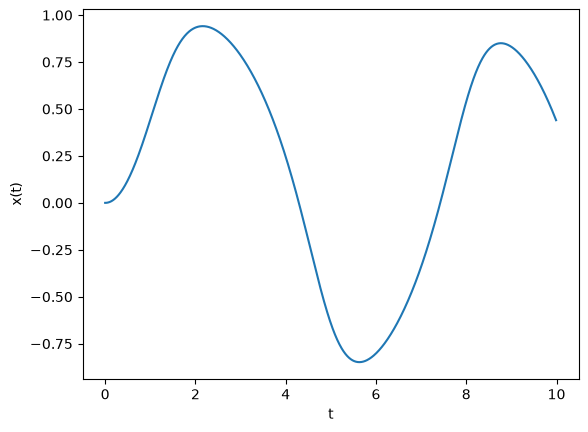

In [1]:
from math import sin
from numpy import arange
import matplotlib.pyplot as plt

def f(x,t):
    return -x**3 + sin(t)

a = 0.0           # Start of the interval
b = 10.0          # End of the interval
N = 1000          # Number of steps
h = (b-a)/N       # Size of a single step
x = 0.0           # Initial condition

tpoints = arange(a,b,h)
xpoints = []
for t in tpoints:
    xpoints.append(x)
    x += h*f(x,t)

plt.plot(tpoints,xpoints)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.show()

# Version 2. Euler's Method using modernized syntax.
### Improvements
1. Used **`np.linspace` instead of `np.arange`** to prevent off-by-one errors in the $t$-axis caused by  floating-point step drift. This guarantees an exact array size `n_steps`. 
2. Used **Matplotlib object-oriented API (`fig`, `ax`)** instead of the stateful `pyplot` interface. Explicit `Figure` and `Axes` instances offer better control, readability, and scalability when handling complex or multi-panel plots.
3. Used explicit **type hints** to clarify the expected data types of function arguments and return values.
4. **Pre-allocated memory** with `np.empty` to improve performance. The old way initialized an empty array `x_points = []` and appended to it inside a 1,000-step loop.
5. **Encapsulation and reusability** improvements: put the solver inside a function and prevented Matplotlib from drawing plots if the code were imported into another program.

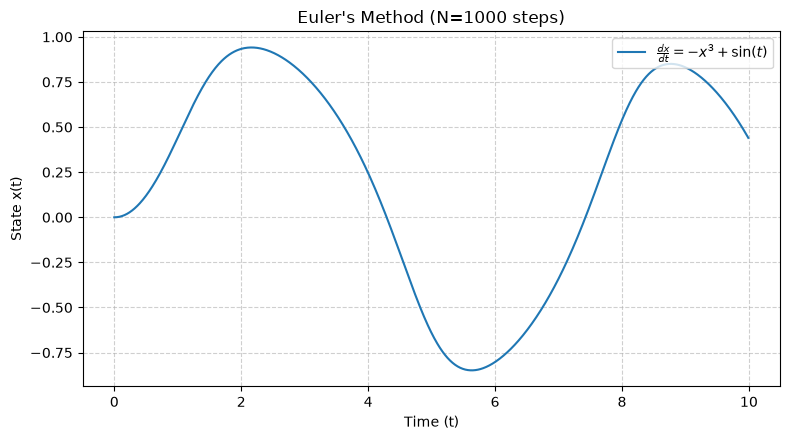

In [2]:
# Version 2: Euler's Method using modernized syntax.

from typing import Tuple
import matplotlib.pyplot as plt
import numpy as np


def solve_euler_modern(
    t_start: float = 0.0,
    t_end: float = 10.0,
    n_steps: int = 1000,
    x0: float = 0.0,
) -> Tuple[np.ndarray, np.ndarray]:
    """Uses Euler's method to solve ODE dx/dt = f(x, t) where f(x, t) is defined in the function above.
    Returns Tuple[time points array, solved values x(t) array].
    """
    
    def f(x: float | np.ndarray, t: float | np.ndarray) -> float | np.ndarray:
        """Calculates the right-hand side of the ODE dx/dt = f(x, t) where f(x, t) = -x^3 + sin(t)."""
        return -(x**3) + np.sin(t)

    # Use linspace to prevent off-by-one errors caused by floating-point step drift
    # Because of the retstep=True flag, we get
    # t_points: array of time points. h: exact calculated step size (scalar) between points
    t_points, h = np.linspace(t_start, t_end, n_steps, retstep=True, endpoint=False)

    # Pre-allocate memory to avoid list append overhead
    x_points = np.empty(n_steps, dtype=np.float64)
    
    x = x0
    for i, t in enumerate(t_points):
        x_points[i] = x
        x += h * f(x, t)
        
    return t_points, x_points


if __name__ == "__main__":
    t_points, x_points = solve_euler_modern()
    
    # Modern object-oriented Matplotlib API
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(t_points, x_points, label=r"$\frac{dx}{dt} = -x^3 + \sin(t)$", color="tab:blue")
    ax.set_title(f"Euler's Method (N={len(t_points)} steps)")
    ax.set_xlabel("Time (t)")
    ax.set_ylabel("State x(t)")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# Version 3. Vectorization and batch computing.

We cannot avoid a `for` loop, because each step of Euler Method depends on the previous step:
$$x_{k+1} = x_k + h*f(x_k, t_k)$$

Even though iteration is necessary, we can vectorize aspects of our computation and take advantage of SIMD and NumPy's C-speed capabilities:
1. Vectorize the term $\sin(t)$ in advance for all $t$.
2. If we happen to have multiple initial conditions $x_0$ (`x0_batch` array), we can apply the Euler Method to all trajectories in parallel.



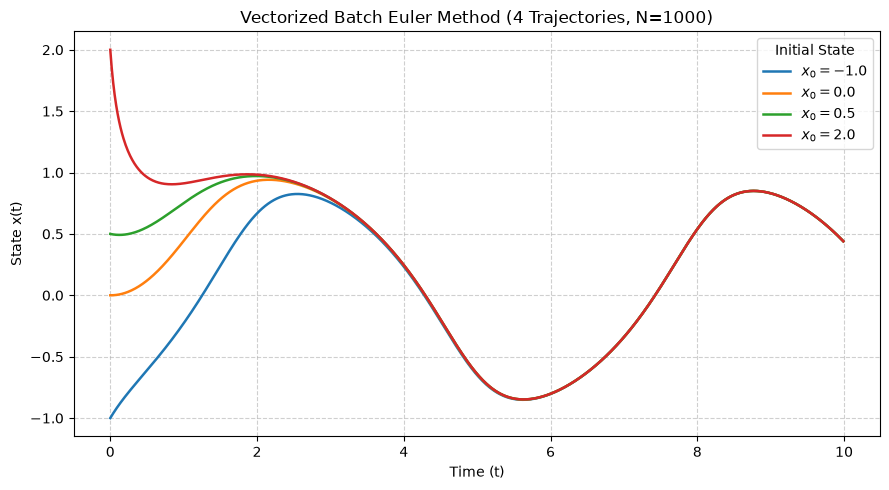

In [3]:
# Version 3. Vectorization and batch computing.

from typing import Tuple
import matplotlib.pyplot as plt
import numpy as np


def solve_euler_vectorized_batch(
    t_start: float = 0.0,
    t_end: float = 10.0,
    n_steps: int = 1000,
    x0_batch: np.ndarray | None = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Optimized Euler's method that uses vector pre-computation and allows for batch trajectory
    calculation across multiple initial conditions. The array of multiple initial conditions 
    is assumed to be supplied by the user.
    
    This version uses vector pre-computation for the sin(t) term in function 
    f(x, t) = -x^3 + sin(t).
    
    Returns Tuple[time points array, 2D array for all trajectories x(t)].
    """

    if x0_batch is None:
        x0_batch = np.array([0.0, 0.5, 1.0, 1.5])
    
    # Because of the retstep=True flag, we get
    # t_points: array of time points. h: exact calculated step size (scalar) between points
    t_points, h = np.linspace(t_start, t_end, n_steps, retstep=True, endpoint=False)

    sin_t = np.sin(t_points)  # vectorized for C-speed

    # Pre-allocate 2D grid for multiple trajectories
    num_trajectories = len(x0_batch)
    x_grid = np.empty((n_steps, num_trajectories), dtype=np.float64)

    # Prepare an independent copy of x0_batch array w/ 64bit precision
    x = x0_batch.astype(np.float64).copy()

    # Euler iteration vectorized across all trajectories
    for i in range(n_steps):
        x_grid[i] = x
        x += h * (-(x**3) + sin_t[i])

    return t_points, x_grid


if __name__ == "__main__":

    init_conds = np.array([-1.0, 0.0, 0.5, 2.0]) #user-defined initial conditions
    t_points, x_grid = solve_euler_vectorized_batch(x0_batch=init_conds)
    fig, ax = plt.subplots(figsize=(9, 5))

    # x_grid has shape (n_steps, num_trajectories)
    # We loop over each trajectory to give each its own color, label and legend entry.
    for i, x0 in enumerate(init_conds):
        ax.plot(t_points, x_grid[:, i], label=f"$x_0 = {x0}$", linewidth=1.8)

    ax.set_title(f"Vectorized Batch Euler Method ({len(init_conds)} Trajectories, N={len(t_points)})")
    ax.set_xlabel("Time (t)")
    ax.set_ylabel("State x(t)")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(title="Initial State", loc="upper right")

    plt.tight_layout()
    plt.show()


# Comparing the times to execute the 3 Versions.

In [4]:
import timeit
from math import sin
from numpy import arange
import numpy as np

# Define a wrapper for Newman's V1 script to benchmark it cleanly
def solve_euler_v1_newman(a=0.0, b=10.0, N=1000, x0=0.0):
    """Wrapper function executing Version 1, Newman's baseline code"""
    def f_v1(x, t):
        return -x**3 + sin(t)

    h = (b - a) / N
    x = x0
    tpoints = arange(a, b, h)
    xpoints = []
    for t in tpoints:
        xpoints.append(x)
        x += h * f_v1(x, t)
    return tpoints, xpoints

a, b, N, x0 = 0.0, 10.0, 1000, 0.0  # standardized parameters
x0_batch = np.array([-1.0, 0.0, 0.5, 2.0])  # multiple trajectory trial for Version 3

print(f"Benchmarking Euler Solvers (N={N} steps)\n")

# Version 1. Newman Baseline, 1 trajectory
t_v1 = %timeit -o -q solve_euler_v1_newman(a, b, N, x0)
print(f"Version 1 (Newman Baseline, 1 trajectory: {t_v1.average * 1e3:.3f} ms")

# Version 2. Modern Scalar, 1 trajectory
t_v2 = %timeit -o -q solve_euler_modern(a, b, N, x0)
print(f"Version 2 (Modern Scalar, 1 trajectory): {t_v2.average * 1e3:.3f} ms")

# Version 3. Vectorized Batch, 4 trajectories
t_v3 = %timeit -o -q solve_euler_vectorized_batch(a, b, N, x0_batch)
print(f"Version 3 (Vectorized Batch, {len(x0_batch)} trajectories): {t_v3.average * 1e3:.3f} ms")

# Calculate amortized cost per trajectory for Version 3
v3_per_traj = (t_v3.average / len(x0_batch)) * 1e3
print(f"\nV3 Amortized time: {v3_per_traj:.3f} ms per trajectory")


Benchmarking Euler Solvers (N=1000 steps)

Version 1 (Newman Baseline, 1 trajectory: 0.290 ms
Version 2 (Modern Scalar, 1 trajectory): 1.009 ms
Version 3 (Vectorized Batch, 4 trajectories): 6.228 ms

V3 Amortized time: 1.557 ms per trajectory


# Uh-oh, disappointing benchmark results!
## Will fix next update!
In the benchmarking tests above, the original V1 Euler calculation outperforms the supposedly improved V2 and V3 code. Thoughts on what went wrong:

## `math.sin(t)` vs. `np.sin(t)`
Version 2 invokes a scalar `np.sin(t)` inside a `for` loop. **`np.sin(t)` is optimized for vector calculations, but is slow for single scalar computation.** There's a lot of overhead in creating multiple 0D ndarrays just to hold the scalar input `t` as well as the scalar `float` resulting from the sine operation. There are also multiple C-API calls which add to the overhead.

**Version 1 correctly uses `math.sin(t)`, which is optimized for single scalar numbers**, inside the `for` loop. There's virtually zero overhead.

## In V3, NumPy allocates and destroys 3 new temporary arrays per iteration.
* Each Euler iteration invokes the calculation:
`x += h * (-(x**3) + sin_t[i])`

* Because NumPy arrays are mutable, *the `*`, `**`, and `+` binary operators each create a new array* to hold its intermediate result.

* Over 1,000 iterations, this means 3,000 temporary arrays are allocated, populated and destroyed, adding noticeable of overhead.

* Solution: use in-place operators `*=` and `+=`. Also reuse a single buffer using NumPy's `out=` parameter.